# Random-Forest Baseline v3

Dieses Notebook bewertet `v3` mit der zusammengelegten Klasse `Kein Schlag / Schlaeger drehen` und vergleicht die Ergebnisse direkt mit `v1` und `v2`.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

def find_repo_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "src" / "random_forest_baseline_v3").exists():
            return candidate
    raise FileNotFoundError("Repo root mit src/random_forest_baseline_v3 wurde nicht gefunden.")

repo_root = find_repo_root(Path.cwd())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.random_forest_baseline.config import BaselineConfig
from src.random_forest_baseline.data import prepare_dataset
from src.random_forest_baseline.modeling import evaluate_grouped_dataset, save_confusion_matrix_plot

config = BaselineConfig.from_json(repo_root / "baseline_models/random_forest_v3/config.json")
config


BaselineConfig(data_dir='Daten/Daten_Labeled', output_dir='baseline_models/random_forest_v3/output', model_output_path='baseline_models/random_forest_v3/output/random_forest_model.pkl', window_before_s=0.5, window_after_s=0.5, min_window_rows=25, labels=['Vorhand', 'Rueckhand', 'Aufschlag von unten', 'Kein Schlag / Schlaeger drehen'], label_aliases={'Schlaeger drehen': 'Kein Schlag / Schlaeger drehen', 'Kein Schlag / Other': 'Kein Schlag / Schlaeger drehen'}, excluded_labels=['Unsicher'], min_samples_per_label=10, min_sessions_per_label=2, random_state=42, n_estimators=600, max_depth=12, min_samples_split=10, min_samples_leaf=3, max_features='log2', criterion='entropy', class_weight='balanced_subsample')

In [2]:
search_results_path = repo_root / "baseline_models/random_forest_v3/output/search_results.csv"
search_summary_path = repo_root / "baseline_models/random_forest_v3/output/search_summary.json"

if search_results_path.exists():
    display(pd.read_csv(search_results_path).head(10))

if search_summary_path.exists():
    search_summary = json.loads(search_summary_path.read_text())
    display(pd.DataFrame([search_summary["best_metrics"]]))
    display(pd.DataFrame([search_summary["best_params"]]))


,search_rank,candidate_rank_seed_order,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,criterion,class_weight,event_count,feature_count,session_count,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,1,9,600,10,3,log2,12.0,entropy,balanced_subsample,377.0,164.0,3.0,0.957560,0.952121,0.955942,0.952121,0.953066,0.957772
1,2,12,800,4,3,log2,12.0,gini,balanced,377.0,164.0,3.0,0.954907,0.956920,0.948346,0.956920,0.951647,0.955407
2,3,7,300,4,4,log2,8.0,gini,balanced,377.0,164.0,3.0,0.952255,0.950341,0.946716,0.950341,0.947590,0.952757
3,4,4,300,6,4,sqrt,8.0,entropy,balanced_subsample,377.0,164.0,3.0,0.941645,0.943298,0.936644,0.943298,0.938247,0.942776
4,5,11,200,4,1,log2,NaN,entropy,balanced,377.0,164.0,3.0,0.946950,0.925805,0.950359,0.925805,0.935937,0.946865
5,6,10,400,2,1,sqrt,8.0,entropy,NaN,377.0,164.0,3.0,0.944297,0.929443,0.941854,0.929443,0.934192,0.944518
6,7,13,800,4,4,0.5,8.0,gini,NaN,377.0,164.0,3.0,0.941645,0.928104,0.939641,0.928104,0.933157,0.941472
7,8,1,200,6,4,0.5,12.0,gini,NaN,377.0,164.0,3.0,0.936340,0.926789,0.936715,0.926789,0.930759,0.935813
8,9,14,600,6,2,0.5,12.0,entropy,balanced,377.0,164.0,3.0,0.938992,0.944896,0.913251,0.944896,0.926392,0.940009
9,10,2,200,2,4,0.5,12.0,gini,balanced,377.0,164.0,3.0,0.923077,0.926734,0.921398,0.926734,0.921421,0.924839


,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,event_count,feature_count,session_count
0,0.95756,0.952121,0.955942,0.952121,0.953066,0.957772,377.0,164.0,3.0


,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,criterion,class_weight
0,600,12,10,3,log2,entropy,balanced_subsample


In [3]:
config_v2 = BaselineConfig.from_json(repo_root / "baseline_models/random_forest_v2/config.json")
dataset_v2 = prepare_dataset(config_v2)
dataset_v3 = prepare_dataset(config)

label_compare = pd.concat(
    [
        dataset_v2.label_summary.assign(model="v2"),
        dataset_v3.label_summary.assign(model="v3"),
    ],
    ignore_index=True,
)
display(label_compare)
display(dataset_v3.metadata.head())
print(f"v3 Events: {len(dataset_v3.labels)} | Sessions: {dataset_v3.groups.nunique()} | Features: {dataset_v3.features.shape[1]}")


,label_name,total_events,session_count,model
0,Vorhand,170,3,v2
1,Rueckhand,95,3,v2
2,Schlaeger drehen,53,2,v2
3,Aufschlag von unten,38,2,v2
4,Kein Schlag / Other,21,3,v2
5,Vorhand,170,3,v3
6,Rueckhand,95,3,v3
7,Aufschlag von unten,38,2,v3
8,Kein Schlag / Schlaeger drehen,74,3,v3


,session_name,event_index,event_time_s,window_start_s,window_end_s,window_rows,label_name
0,fritz_1_Labeled.csv,11534,116.219257,115.719257,116.719257,99,Rueckhand
1,fritz_1_Labeled.csv,11832,119.222006,118.722006,119.722006,99,Rueckhand
2,fritz_1_Labeled.csv,12133,122.254987,121.754987,122.754987,99,Vorhand
3,fritz_1_Labeled.csv,12499,125.942926,125.442926,126.442926,99,Vorhand
4,fritz_1_Labeled.csv,12805,129.026281,128.526281,129.526281,99,Vorhand


v3 Events: 377 | Sessions: 3 | Features: 164


In [4]:
result = evaluate_grouped_dataset(dataset_v3, config)
display(pd.DataFrame([result.overall_metrics]))
display(result.classification_report)
display(result.fold_metrics)


,event_count,feature_count,session_count,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,377.0,164.0,3.0,0.95756,0.952121,0.955942,0.952121,0.953066,0.957772


,label,precision,recall,f1-score,support
0,Vorhand,0.982558,0.994118,0.988304,170.00000
1,Rueckhand,0.977011,0.894737,0.934066,95.00000
2,Aufschlag von unten,1.000000,0.973684,0.986667,38.00000
3,Kein Schlag / Schlaeger drehen,0.864198,0.945946,0.903226,74.00000
4,accuracy,0.957560,0.957560,0.957560,0.95756
5,macro avg,0.955942,0.952121,0.953066,377.00000
6,weighted avg,0.959686,0.957560,0.957772,377.00000


,fold,test_session,train_events,test_events,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,1,fritz_1_Labeled.csv,230,147,0.918367,0.927792,0.919301,0.927792,0.913270,0.920962
1,2,fritz_2_Labeled.csv,292,85,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
2,3,fritz_3_Labeled.csv,232,145,0.972414,0.976744,0.973830,0.976744,0.974331,0.972113


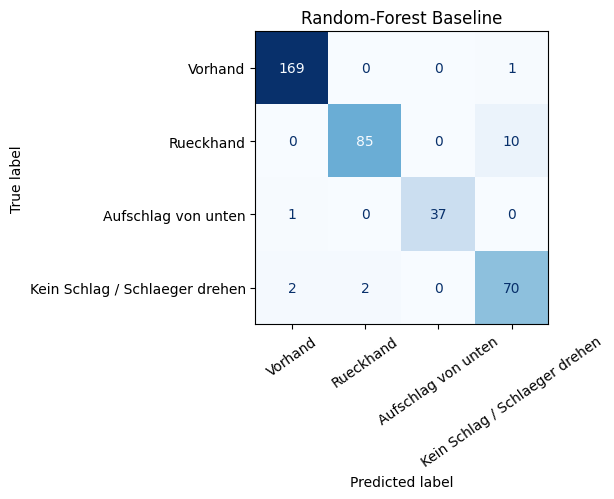

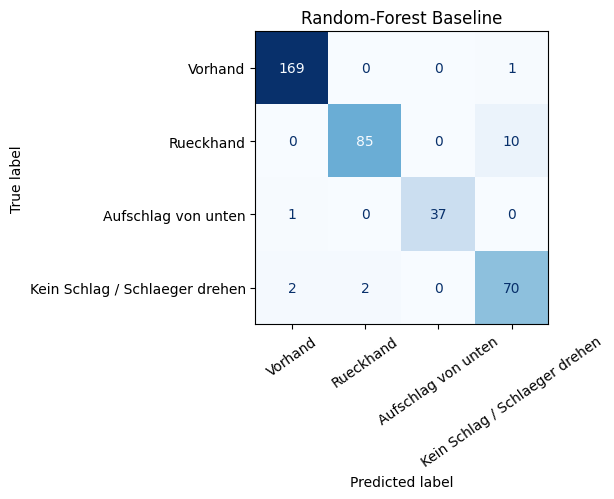

In [5]:
figure = save_confusion_matrix_plot(result.confusion_matrix)
figure


In [6]:
metric_paths = {
    "v1": repo_root / "baseline_models/random_forest/output/metrics.json",
    "v2": repo_root / "baseline_models/random_forest_v2/output/metrics.json",
    "v3": repo_root / "baseline_models/random_forest_v3/output/metrics.json",
}

rows = []
for model_name, path in metric_paths.items():
    payload = json.loads(path.read_text())
    rows.append({"model": model_name, **payload["overall_metrics"]})

comparison = pd.DataFrame(rows).set_index("model").loc[["v1", "v2", "v3"]]
comparison["accuracy_vs_v2"] = comparison["accuracy"] - comparison.loc["v2", "accuracy"]
comparison["macro_f1_vs_v2"] = comparison["macro_f1"] - comparison.loc["v2", "macro_f1"]
comparison["balanced_accuracy_vs_v2"] = comparison["balanced_accuracy"] - comparison.loc["v2", "balanced_accuracy"]
display(comparison)


,event_count,feature_count,session_count,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,accuracy_vs_v2,macro_f1_vs_v2,balanced_accuracy_vs_v2
model,,,,,,,,,,,,
v1,377.0,164.0,3.0,0.885942,0.741074,0.737571,0.741074,0.737386,0.886712,-0.005305,-0.014678,-0.022018
v2,377.0,164.0,3.0,0.891247,0.763091,0.745626,0.763091,0.752064,0.889265,0.000000,0.000000,0.000000
v3,377.0,164.0,3.0,0.957560,0.952121,0.955942,0.952121,0.953066,0.957772,0.066313,0.201002,0.189030


In [7]:
feature_importances_path = repo_root / "baseline_models/random_forest_v3/output/feature_importances.csv"
if feature_importances_path.exists():
    display(pd.read_csv(feature_importances_path).head(20))


,feature,importance
0,motionGravityZ(G)__std,0.038301
1,motionRotationRateY(rad/s)__mean,0.035111
2,motionQuaternionW(R)__std,0.031330
3,motionRotationRateY(rad/s)__min,0.031122
4,motionRotationRateY(rad/s)__max,0.027089
5,motionPitch(rad)__energy,0.024969
6,motionUserAccelerationX(G)__mean,0.024820
7,motionRotationRateY(rad/s)__energy,0.024151
8,motionGravityY(G)__energy,0.023617
9,motionRotationRateY(rad/s)__std,0.022658


## Anpassung

Wenn ihr die gemergte Klasse wieder aufteilen oder andere Fenster-/Forest-Parameter testen wollt, passt zuerst `baseline_models/random_forest_v3/config.json` an und fuehrt die Zellen erneut aus.